In [1]:
# ==========================================
# Fake News Detection Using NLP
# Phase 7 - Model Evaluation
# ==========================================

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
rf = joblib.load("../models/fake_news_model.pkl")

X_test = joblib.load("../models/X_test.pkl")
y_test = joblib.load("../models/y_test.pkl")

print("Model Loaded Successfully")
print("Testing Samples :", X_test.shape[0])

Model Loaded Successfully
Testing Samples : 8837


In [3]:
y_pred = rf.predict(X_test)

print("Prediction Completed Successfully.")

Prediction Completed Successfully.


In [4]:
accuracy = accuracy_score(y_test, y_pred)

print("="*60)
print("Model Accuracy")
print("="*60)

print(f"Accuracy : {accuracy*100:.2f}%")

Model Accuracy
Accuracy : 99.82%


In [5]:
precision = precision_score(y_test, y_pred)

print(f"Precision : {precision*100:.2f}%")

Precision : 99.74%


In [6]:
recall = recall_score(y_test, y_pred)

print(f"Recall : {recall*100:.2f}%")

Recall : 99.88%


In [7]:
f1 = f1_score(y_test, y_pred)

print(f"F1 Score : {f1*100:.2f}%")

F1 Score : 99.81%


In [8]:
print("="*60)
print("Classification Report")
print("="*60)

print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4554
           1       1.00      1.00      1.00      4283

    accuracy                           1.00      8837
   macro avg       1.00      1.00      1.00      8837
weighted avg       1.00      1.00      1.00      8837



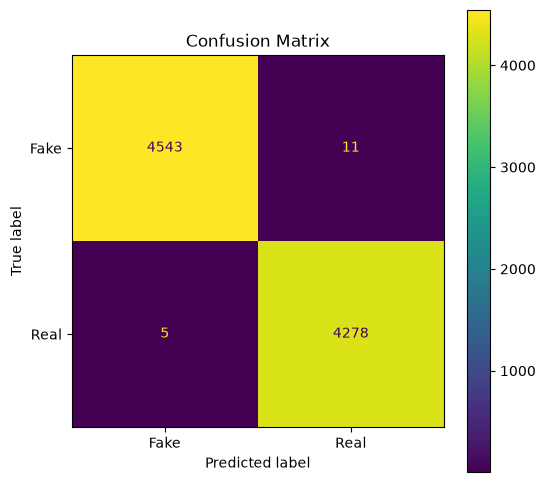

In [9]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake","Real"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(ax=ax)

plt.title("Confusion Matrix")

plt.show()

In [10]:
summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        accuracy*100,
        precision*100,
        recall*100,
        f1*100
    ]

})

summary

,Metric,Value
0,Accuracy,99.818943
1,Precision,99.743530
2,Recall,99.883259
3,F1 Score,99.813346


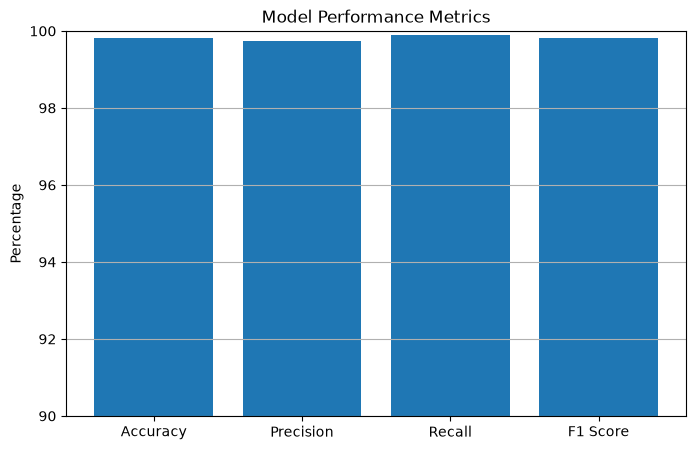

In [11]:
plt.figure(figsize=(8,5))

plt.bar(
    summary["Metric"],
    summary["Value"]
)

plt.ylim(90,100)

plt.ylabel("Percentage")

plt.title("Model Performance Metrics")

plt.grid(axis="y")

plt.show()

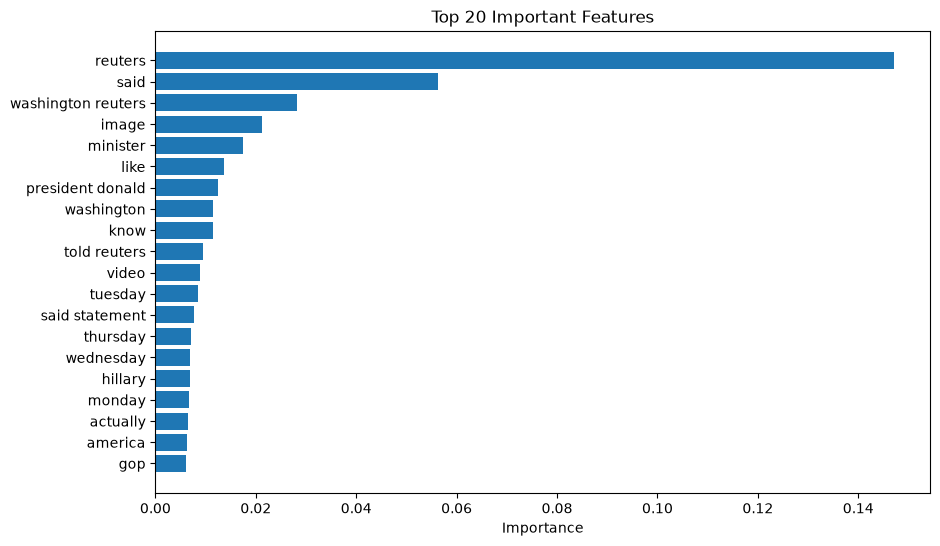

In [12]:
import numpy as np

vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

feature_names = vectorizer.get_feature_names_out()

importance = rf.feature_importances_

indices = np.argsort(importance)[-20:]

plt.figure(figsize=(10,6))

plt.barh(
    feature_names[indices],
    importance[indices]
)

plt.title("Top 20 Important Features")

plt.xlabel("Importance")

plt.show()

In [13]:
print("="*60)
print("Model Evaluation Observations")
print("="*60)

print("1. Random Forest achieved the highest classification accuracy.")
print("2. Precision and Recall values indicate highly reliable predictions.")
print("3. F1-score confirms balanced classification performance.")
print("4. The confusion matrix shows very few misclassified articles.")
print("5. Feature importance highlights the most influential TF-IDF terms.")
print("6. The trained model is suitable for fake news prediction.")
print("7. The evaluation phase has been completed successfully.")

print("\nModel Evaluation Completed Successfully.")

Model Evaluation Observations
1. Random Forest achieved the highest classification accuracy.
2. Precision and Recall values indicate highly reliable predictions.
3. F1-score confirms balanced classification performance.
4. The confusion matrix shows very few misclassified articles.
5. Feature importance highlights the most influential TF-IDF terms.
6. The trained model is suitable for fake news prediction.
7. The evaluation phase has been completed successfully.

Model Evaluation Completed Successfully.
